In [15]:
# bibliotecas
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.layers import Input, Conv2D, Dense, Flatten, Dropout, MaxPooling2D, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.models import Model

In [16]:
# treinamento e importação
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()
x_train, x_test = x_train / 255.0, x_test / 255.0
y_train, y_test = y_train.flatten(), y_test.flatten()
print(x_train.shape)

(50000, 32, 32, 3)


In [17]:
#classes
K = len(set(y_train))
print('classes:', K)

classes: 10


In [18]:
i = Input(shape=x_train[0].shape)

# bloco 1 kernel maior pra pegar features amplas logo de cara
x = Conv2D(32, (5, 5), activation='relu', padding='same')(i)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)

# bloco 2
x = Conv2D(64, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)
x = MaxPooling2D(2, 2)(x)

# bloco 3
x = Conv2D(128, (3, 3), activation='relu', padding='same')(x)
x = BatchNormalization()(x)

# globalAveragePooling  mais leve que Flatten
x = GlobalAveragePooling2D()(x)

x = Dropout(0.4)(x)
x = Dense(256, activation='relu')(x)
x = Dropout(0.2)(x)
x = Dense(K, activation='softmax')(x)

model = Model(i, x)
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_4 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 32, 32, 32)     │         2,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_12          │ (None, 32, 32, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_8 (MaxPooling2D)  │ (None, 16, 16, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 16, 16, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_13          │ (None, 16, 16, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_9 (MaxPooling2D)  │ (None, 8, 8, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 8, 8, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_14          │ (None, 8, 8, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 128)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 131,274 (512.79 KB)

 Trainable params: 130,826 (511.04 KB)

 Non-trainable params: 448 (1.75 KB)

In [20]:
# augmentation com zoom
datagen = tf.keras.preprocessing.image.ImageDataGenerator(
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True,
    zoom_range=0.1
)
train_gen = datagen.flow(x_train, y_train, batch_size=32)
steps = x_train.shape[0] // 32

model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

r = model.fit(train_gen, steps_per_epoch=steps, epochs=15,
              validation_data=(x_test, y_test))

Epoch 1/15


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 131s 82ms/step - accuracy: 0.3649 - loss: 1.7177 - val_accuracy: 0.5144 - val_loss: 1.3411
Epoch 2/15
   1/1562 ━━━━━━━━━━━━━━━━━━━━ 2:18 89ms/step - accuracy: 0.4375 - loss: 1.4058

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4375 - loss: 1.4058 - val_accuracy: 0.5245 - val_loss: 1.3137
Epoch 3/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 119s 76ms/step - accuracy: 0.5447 - loss: 1.2679 - val_accuracy: 0.6051 - val_loss: 1.0992
Epoch 4/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5000 - loss: 1.3713 - val_accuracy: 0.6180 - val_loss: 1.0610
Epoch 5/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 120s 77ms/step - accuracy: 0.5944 - loss: 1.1351 - val_accuracy: 0.5775 - val_loss: 1.1649
Epoch 6/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6875 - loss: 0.8593 - val_accuracy: 0.5722 - val_loss: 1.1772
Epoch 7/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 131s 84ms/step - accuracy: 0.6283 - loss: 1.0468 - val_accuracy: 0.6032 - val_loss: 1.1640
Epoch 8/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.6875 - loss: 0.8244 - val_accuracy: 0.5975 - val_loss: 1.1933
Epoch 9/15
1562/1562 ━━━━━━━━━━━━━━━━━━━━ 132s 82ms/step - accuracy: 0.6524 - loss: 0.9860 -

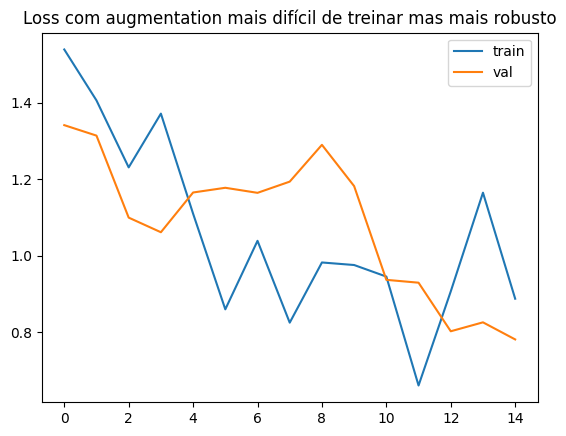

In [24]:
# perda
plt.plot(r.history['loss'], label='train')
plt.plot(r.history['val_loss'], label='val')
plt.title('Loss com augmentation mais difícil de treinar mas mais robusto')
plt.legend()
plt.show()

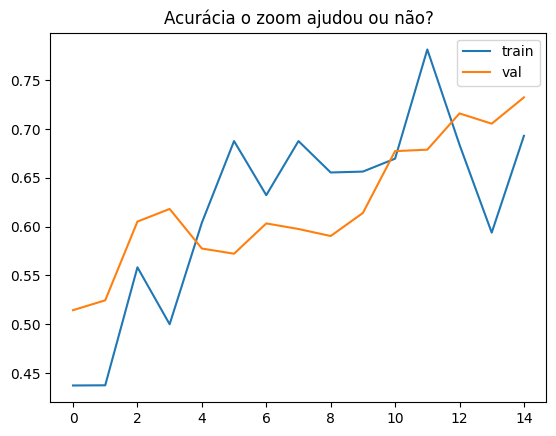

In [25]:
# acurácia
plt.plot(r.history['accuracy'], label='train')
plt.plot(r.history['val_accuracy'], label='val')
plt.title('Acurácia o zoom ajudou ou não?')
plt.legend()
plt.show()

In [28]:
from sklearn.metrics import confusion_matrix
import itertools

313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step


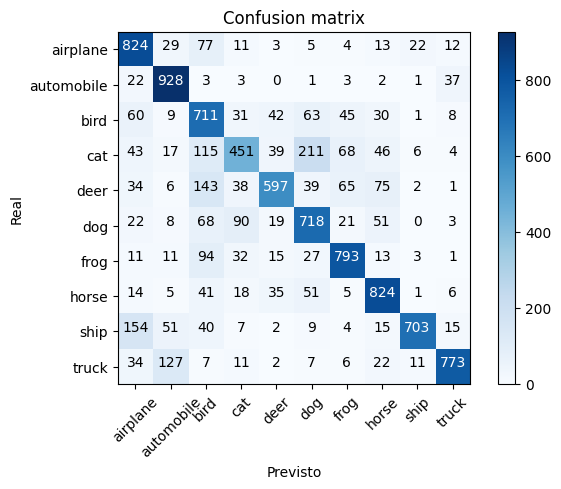

In [29]:

def plot_confusion_matrix(cm, classes, normalize=False,
                          title='Confusion matrix', cmap=plt.cm.Blues):
    if normalize:
        cm = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis]
    plt.imshow(cm, interpolation='nearest', cmap=cmap)
    plt.title(title)
    plt.colorbar()
    tick_marks = np.arange(len(classes))
    plt.xticks(tick_marks, classes, rotation=45)
    plt.yticks(tick_marks, classes)
    fmt = '.2f' if normalize else 'd'
    thresh = cm.max() / 2.
    for i, j in itertools.product(range(cm.shape[0]), range(cm.shape[1])):
        plt.text(j, i, format(cm[i, j], fmt),
                 horizontalalignment='center',
                 color='white' if cm[i, j] > thresh else 'black')
    plt.tight_layout()
    plt.ylabel('Real')
    plt.xlabel('Previsto')
    plt.show()

labels = ['airplane','automobile','bird','cat','deer',
          'dog','frog','horse','ship','truck']

p_test = model.predict(x_test).argmax(axis=1)
cm = confusion_matrix(y_test, p_test)
plot_confusion_matrix(cm, labels)

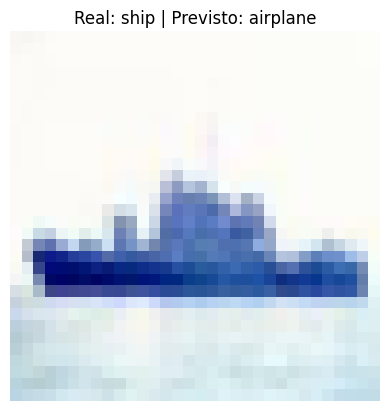

In [30]:
# erro do modelo analisando onde errou
misclassified_idx = np.where(p_test != y_test)[0]
idx = np.random.choice(misclassified_idx)
plt.imshow(x_test[idx])
plt.title(f'Real: {labels[y_test[idx]]} | Previsto: {labels[p_test[idx]]}')
plt.axis('off')
plt.show()